In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
video_input_file_name = "../../../class.vision/videos/race_car.mp4"
print("cv2 version:", cv.__version__)

cv2 version: 4.12.0


In [9]:
trackers = {
    "DaSiamRPN": cv.TrackerDaSiamRPN_create,
    "Nano": cv.TrackerNano_create,
    "Vit": cv.TrackerVit_create,
    "GOTURN": cv.TrackerGOTURN_create,
}
tracker_type = "GOTURN"
tracker = trackers[tracker_type]()

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\dnn\src\onnx\onnx_importer.cpp:278: error: (-5:Bad argument) Can't read ONNX file: backbone.onnx in function 'cv::dnn::dnn4_v20250619::ONNXImporter::ONNXImporter'


In [12]:
def drawRect(frame, bbox):
    x, y, w, h = bbox
    cv.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

def dispBBox(frame, bbox):
    img = frame.copy()
    drawRect(img, bbox)
    plt.imshow(img[...,::-1]); plt.title(""); plt.axis('off')

In [13]:
# Define a bounding box
bbox = (1300, 405, 160, 120)

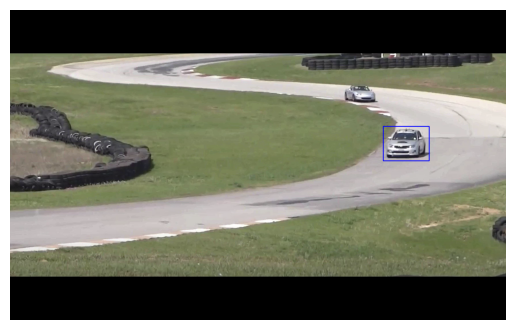

In [14]:
cap = cv.VideoCapture(video_input_file_name)
if cap.isOpened():
    ret, frame0 = cap.read()
    dispBBox(frame0, bbox)
    height, width = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT)), int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    video_output_file_name = 'race_car-' + tracker_type + '.mp4'
    video_writer = cv.VideoWriter(video_output_file_name,cv.VideoWriter_fourcc(*'avc1'), 10, (width, height))
    tracker.init(frame0, bbox)

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        tm = cv.TickMeter()
        tm.start()
        ok, bbox = tracker.update(frame)
        tm.stop()

        # Draw bounding box
        if ok:
            drawRect(frame, bbox)
        else :
            cv.putText(frame, "Tracking failure detected", (80,140), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

        # Display Info
        cv.putText(frame, tracker_type + " Tracker", (80,60), cv.FONT_HERSHEY_SIMPLEX, 1, (50, 170, 50), 3)
        cv.putText(frame, "FPS : " + str(tm.getFPS()), (80,100), cv.FONT_HERSHEY_SIMPLEX, 1, (50, 170, 50), 3)

    video_writer.release()

cap.release()